# 04 — Avaliação e Interpretação

**Dimensão 6 da rúbrica — 20 pontos.**

Aqui a análise deixa de ser técnica e passa a ser de negócio.

In [5]:
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import joblib 

RANDOM_STATE = 42

RAW = Path("..") / "data" / "raw" / "dataset.csv"          
PROCESSED = Path("..") / "data" / "processed"
TARGET = "target"                                            

pd.set_option("display.max_columns", None)

# Importando os dados e o modelo da pasta processed
X_test = pd.read_csv(PROCESSED / "X_test.csv")
y_test = pd.read_csv(PROCESSED / "y_test.csv").squeeze() # squeeze transforma DataFrame em Series
rf_model = joblib.load(PROCESSED / "modelo_rf_vencedor.pkl")

print("Modelo e dados importados com sucesso para o Notebook 04!")

Modelo e dados importados com sucesso para o Notebook 04!


## 1. Métricas no conjunto de teste

Acurácia sozinha engana em base desbalanceada.

**O que faremos nesta etapa?**
Vamos usar o modelo Random Forest treinado (o vencedor da etapa anterior) para prever os resultados na nossa base de teste (`X_test`). Como essa base foi isolada lá no início do projeto, ela simula o mundo real. O resultado aqui refletirá o real desempenho do modelo em produção.

In [6]:
from sklearn.metrics import (
    ConfusionMatrixDisplay, classification_report, roc_auc_score, RocCurveDisplay,
)

# Fazendo as previsões na base de teste
y_pred_final = rf_model.predict(X_test)
y_proba_final = rf_model.predict_proba(X_test)[:, 1]

# Exibindo o Relatório de Classificação
print("--- RELATÓRIO DE CLASSIFICAÇÃO (DADOS INÉDITOS DE TESTE) ---")
print(classification_report(y_test, y_pred_final))

# Exibindo o ROC-AUC Final
roc_auc_final = roc_auc_score(y_test, y_proba_final)
print(f"\nROC-AUC Score Final: {roc_auc_final:.4f}")

--- RELATÓRIO DE CLASSIFICAÇÃO (DADOS INÉDITOS DE TESTE) ---
              precision    recall  f1-score   support

           0       0.99      0.97      0.98     10753
           1       0.20      0.36      0.25       185

    accuracy                           0.96     10938
   macro avg       0.59      0.67      0.62     10938
weighted avg       0.98      0.96      0.97     10938


ROC-AUC Score Final: 0.7658


## 1.1 Justificativa das métricas

_Por que estas e não acurácia pura? Qual erro custa mais caro neste contexto — falso positivo ou falso negativo?_

Em um contexto de concessão de crédito onde a taxa de inadimplência (nossa classe alvo 1) representa apenas cerca de 2% da base, usar a **Acurácia** é um erro técnico. Um modelo que aprovasse todos os clientes indiscriminadamente teria 98% de acurácia, mas quebraria o banco. 

Por isso, avaliamos nosso modelo através das seguintes métricas:
*   **Recall da Classe 1:** É a métrica mais crítica para o negócio. Ela mede nossa capacidade de prever corretamente os maus pagadores. Neste contexto, o **Falso Negativo (classificar um inadimplente como bom pagador) é o erro que custa mais caro**, pois gera perda direta do capital emprestado.
*   **Precision da Classe 1:** Mede a assertividade quando dizemos que alguém não vai pagar. Está ligada ao **Falso Positivo (negar crédito a um bom pagador)**. Custa perda de receita e atrito comercial, mas seu impacto imediato é menor que a perda do capital.
*   **ROC-AUC:** Utilizamos para garantir que o modelo tem uma boa capacidade matemática de distinguir e ordenar quem oferece mais e menos risco.

## 2. Matriz de Confusão

**Para que serve o gráfico da Matriz de Confusão?**
A Matriz de Confusão é uma representação visual que detalha os acertos e erros do nosso modelo, dividindo-os em quatro quadrantes. Em bases de dados com desbalanceamento severo, ela é a melhor forma de entender exatamente *que tipo de erro* o algoritmo está cometendo, saindo dos percentuais abstratos e indo para a contagem real de clientes.

**O que estamos buscando?**
Queremos visualizar o volume exato de **Falsos Negativos** (inadimplentes que o modelo aprovou) e compará-lo com os **Falsos Positivos** (bons clientes que o modelo bloqueou por excesso de cautela).

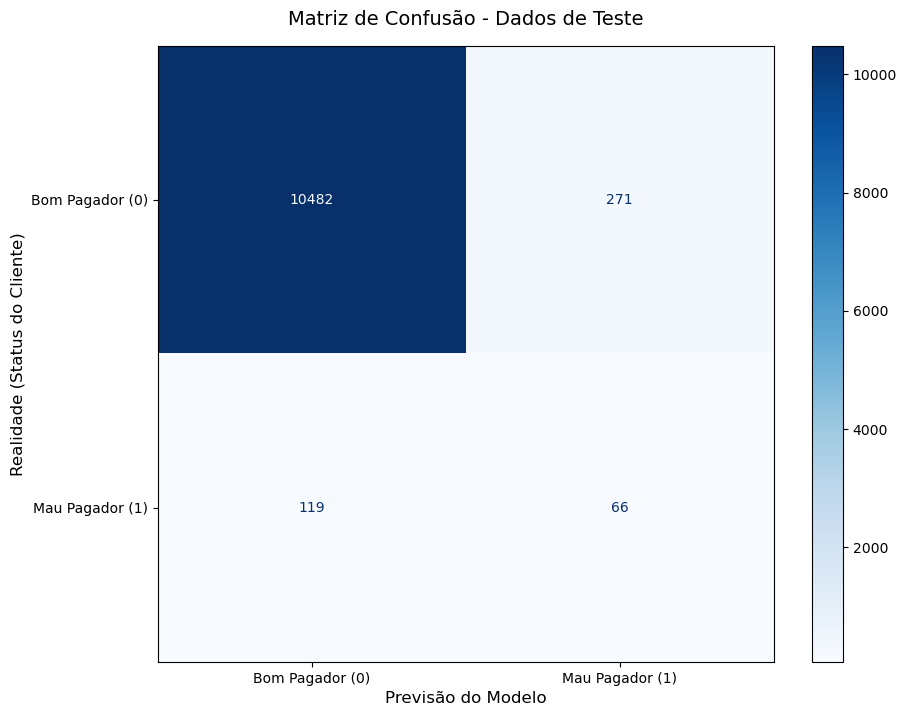

In [13]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

# Criando a figura para melhor visualização
fig, ax = plt.subplots(figsize=(10, 8))

# Gerando e plotando a Matriz de Confusão
disp = ConfusionMatrixDisplay.from_estimator(
    rf_model, 
    X_test, 
    y_test, 
    display_labels=['Bom Pagador (0)', 'Mau Pagador (1)'],
    cmap=plt.cm.Blues,
    ax=ax,
    values_format='d'
)

# Alterando os rótulos dos eixos para português
ax.set_ylabel('Realidade (Status do Cliente)', fontsize=12)
ax.set_xlabel('Previsão do Modelo', fontsize=12)

plt.title('Matriz de Confusão - Dados de Teste', pad=15, fontsize=14)
plt.grid(False) # Remove as linhas de grade
plt.show()

**Leitura e Interpretação para o Negócio:**

Analisando os quadrantes do gráfico, podemos traduzir os números matemáticos para o impacto financeiro real na instituição:

*   **Quadrante Superior Esquerdo (Verdadeiros Negativos - 10.482 clientes):** São os bons pagadores aprovados corretamente pelo modelo. Como a base é majoritariamente de bons clientes, este é o maior volume absoluto.
*   **Quadrante Superior Direito (Falsos Positivos - 271 clientes):** São **bons pagadores que o modelo classificou como risco**. O banco negaria crédito para essas 271 pessoas. O impacto financeiro aqui é o custo de oportunidade (perda da receita de juros) e atrito comercial, porém o capital da instituição não é perdido.
*   **Quadrante Inferior Esquerdo (Falsos Negativos - 119 clientes):** É o **ponto de maior risco**. Representa os 119 clientes que darão calote, mas que o modelo classificou como bons pagadores, aprovando o crédito. É aqui que ocorre a perda financeira direta e irrecuperável do capital emprestado.
*   **Quadrante Inferior Direito (Verdadeiros Positivos - 66 clientes):** Representa o sucesso do modelo na sua tarefa mais difícil: são 66 inadimplentes reais que foram identificados e barrados corretamente, evitando prejuízo direto para o banco.

**Conclusão:** O modelo está funcionando e conseguiu barrar 66 maus pagadores (cerca de 36% do total de calotes possíveis). Para conseguir isso, ele gerou 271 alarmes falsos. Cabe à área de negócios decidir se este *trade-off* está aderente ao apetite de risco da instituição.

## 4. Importância das Variáveis

**O que faremos nesta etapa?**
Modelos baseados em árvores de decisão, como o Random Forest, possuem uma vantagem enorme: eles nos dizem matematicamente quais variáveis foram mais úteis para separar os bons dos maus pagadores. Vamos extrair esses "pesos" e visualizar as 10 características mais determinantes para o risco de crédito.

**Por que isso é importante?**
Um modelo de crédito não pode ser uma "caixa preta". Precisamos garantir que o modelo está tomando decisões baseadas em lógicas de negócio válidas (ex: histórico de pagamentos, renda, comprometimento) e não em ruídos estatísticos.

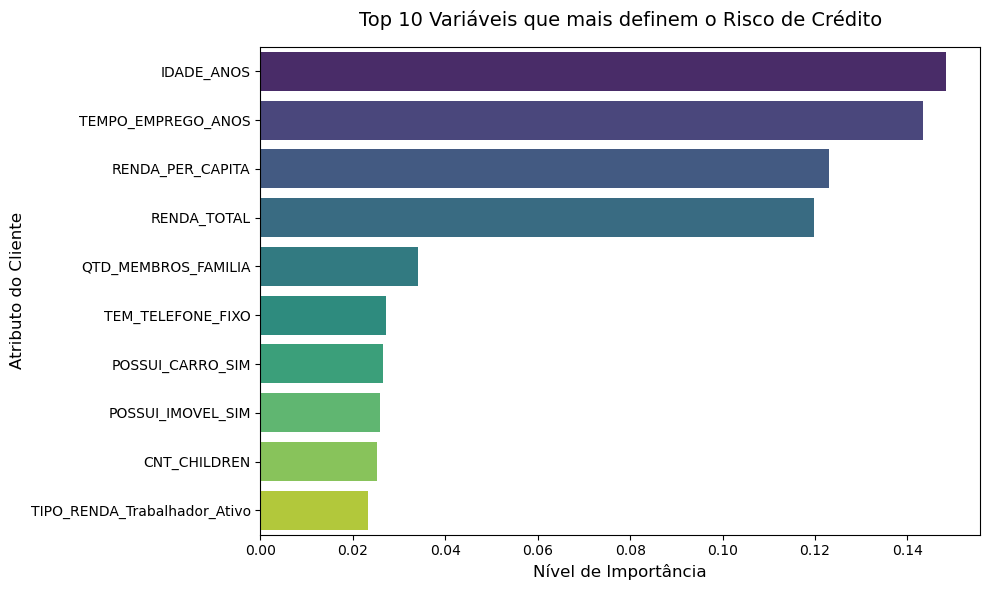

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Extraindo as importâncias e os nomes das features diretamente do modelo e da base de teste
importancias = rf_model.feature_importances_
features = X_test.columns

# Criando um DataFrame para organizar os dados
df_importancias = pd.DataFrame({
    'Variável': features,
    'Importância': importancias
}).sort_values(by='Importância', ascending=False)

# Selecionando as Top 10 variáveis para o gráfico não ficar poluído
top_10_importancias = df_importancias.head(10)

# Criando o gráfico (com a correção do aviso aplicada)
plt.figure(figsize=(10, 6))
sns.barplot(
    x='Importância', 
    y='Variável', 
    data=top_10_importancias, 
    palette='viridis',
    hue='Variável',   # Correção exigida pelo Seaborn
    legend=False      # Oculta a legenda redundante
)

# Customizando o layout
plt.title('Top 10 Variáveis que mais definem o Risco de Crédito', pad=15, fontsize=14)
plt.xlabel('Nível de Importância', fontsize=12)
plt.ylabel('Atributo do Cliente', fontsize=12)
plt.tight_layout()
plt.show()

**Leitura: Quais variáveis mais pesam e isso faz sentido no domínio?**

O gráfico de importância revela que o algoritmo não é uma "caixa preta" arbitrária; ele aprendeu uma lógica de negócio extremamente sólida e coerente com as práticas de avaliação de risco do mercado financeiro[cite: 10].

As quatro variáveis com maior poder de decisão no modelo são[cite: 10]:
1.  **Idade (`IDADE_ANOS`) e Tempo de Emprego (`TEMPO_EMPREGO_ANOS`):** Estes dois fatores dominam o topo do gráfico, representando o pilar da **estabilidade**[cite: 10]. No domínio do crédito, clientes com maior maturidade e tempo de permanência no mesmo emprego apresentam, historicamente, um comportamento financeiro mais previsível e menor propensão ao incumprimento.
2.  **Rendimento (`RENDA_PER_CAPITA` e `RENDA_TOTAL`):** Logo a seguir, surge o pilar da **capacidade de pagamento**[cite: 10]. O modelo compreendeu que o fluxo de caixa do cliente é determinante para suportar uma nova linha de crédito.

Variáveis secundárias, como o tamanho do agregado familiar (`QTD_MEMBROS_FAMILIA`, `CNT_CHILDREN`) e a posse de garantias patrimoniais (`POSSUI_CARRO_SIM`, `POSSUI_IMOVEL_SIM`), funcionam como ajustes finos na pontuação de risco, compondo o perfil socioeconómico do cliente[cite: 10]. Conclui-se que o modelo é altamente explicável e seguro para ser defendido perante uma diretoria de negócios.

## 5. Implicações Práticas

**O que uma área de negócios faria de diferente a partir destes resultados?**

A implementação deste modelo preditivo permite à instituição passar de uma política de concessão de crédito puramente manual ou baseada em regras engessadas, para uma abordagem inteligente e ajustável. 

As principais implicações práticas são:
*   **Gestão Dinâmica do Apetite de Risco:** Como o modelo devolve uma probabilidade de inadimplência clara para cada perfil, o banco pode mover a "régua" de aprovação conforme o cenário econômico. Em meses de maior liquidez, pode ser mais tolerante na concessão; em cenários de crise, pode ser mais restritivo para proteger o caixa, controlando exatamente o nível de risco aceitável.
*   **Fidelização e Venda Cruzada (*Cross-Sell*):** Os clientes classificados com risco quase nulo pelo modelo e que possuem alta estabilidade financeira podem ser aprovados de forma imediata e encaminhados automaticamente para campanhas de produtos complementares (como cartões *premium* ou seguros), otimizando o esforço da equipe comercial.

## 6. Limitações e Próximos Passos

Apesar do bom desempenho geral em separar bons e maus pagadores, o projeto apresenta algumas limitações relacionadas aos dados disponíveis:

*   **Baixo Volume de Histórico de Calotes:** A taxa de inadimplência histórica de apenas 2% limitou a capacidade do modelo de aprender todos os padrões de risco sem acabar negando crédito a alguns bons clientes por precaução. Em desenvolvimentos futuros, o uso de técnicas avançadas para simular e enriquecer os dados de inadimplência ajudaria o sistema a ser ainda mais assertivo.
*   **Ausência de Variáveis Comportamentais Recentes:** Os dados atuais baseiam-se muito no perfil estático e demográfico do cliente. Em um cenário de produção contínua, a inclusão de dados do comportamento financeiro do dia a dia (como histórico de faturas pagas nos últimos 3 meses ou uso do cheque especial) aumentaria drasticamente a capacidade de prever riscos a curto prazo.